In [12]:
import baostock as bs
import pandas as pd

lg = bs.login()

# Load Ping An Bank (sz.000001) daily data for the past year, with forward adjustment
rs = bs.query_history_k_data_plus(
    "sz.000001",
    "date,open,high,low,close,volume",
    start_date="2024-04-01",
    end_date="2025-04-01",
    frequency="d",
    adjustflag="2"        # 前复权
)

data_list = []
while (rs.error_code == '0') and rs.next():
    data_list.append(rs.get_row_data())

df = pd.DataFrame(data_list, columns=rs.fields)


# Load Tuo Er Si (300229.SZ) daily data for the past year, with forward adjustment
tes = bs.query_history_k_data_plus(
    "sz.300229",
    "date,open,high,low,close,volume",
    start_date="2024-04-01",
    end_date="2025-04-01",
    frequency="d",
    adjustflag="2"        # 前复权
)

data_list = []
while (tes.error_code == '0') and tes.next():
    data_list.append(tes.get_row_data())

df_small = pd.DataFrame(data_list, columns=tes.fields)

bs.logout()

# Clean
for col in ['open', 'high', 'low', 'close', 'volume']:
    df[col] = pd.to_numeric(df[col])
    df_small[col] = pd.to_numeric(df_small[col])
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')
df_small['date'] = pd.to_datetime(df_small['date'])
df_small = df_small.set_index('date')

# Set 20-day moving average
df['ma_20'] = df['close'].rolling(20).mean()
df_small['ma_20'] = df_small['close'].rolling(20).mean()

login success!
logout success!


In [13]:
import matplotlib
import matplotlib.pyplot as plt

# Style first, because it resets font-related rcParams
plt.style.use('seaborn-v0_8-whitegrid')


# Then fonts, so they win
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False


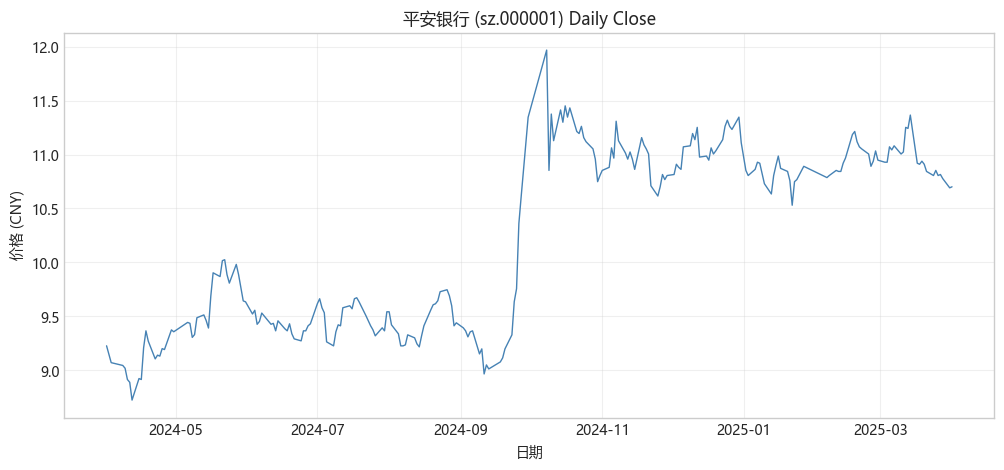

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df.index, df['close'], color='steelblue', linewidth=1)
ax.set_title('平安银行 (sz.000001) Daily Close')
ax.set_xlabel('日期')
ax.set_ylabel('价格 (CNY)')
ax.grid(True, alpha=0.3)

plt.show()

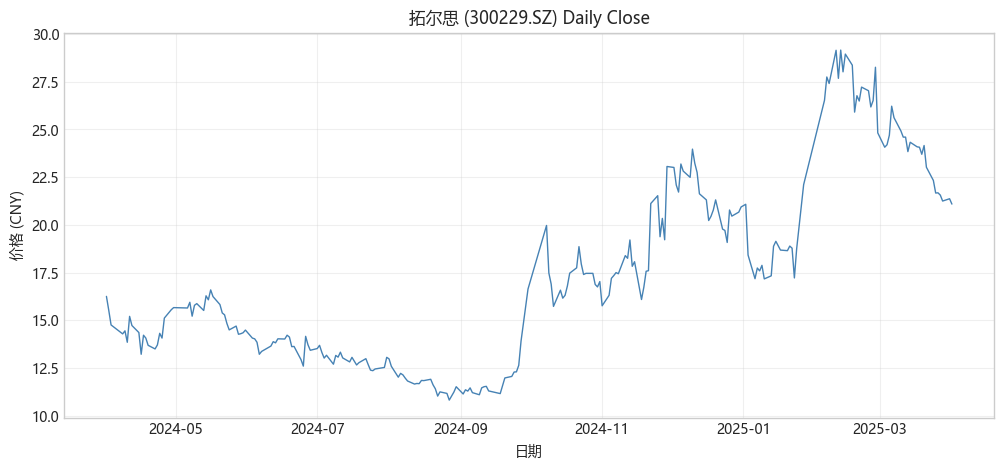

In [21]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df_small.index, df_small['close'], color='steelblue', linewidth=1)
ax.set_title('拓尔思 (300229.SZ) Daily Close')
ax.set_xlabel('日期')
ax.set_ylabel('价格 (CNY)')
ax.grid(True, alpha=0.3)

plt.show()

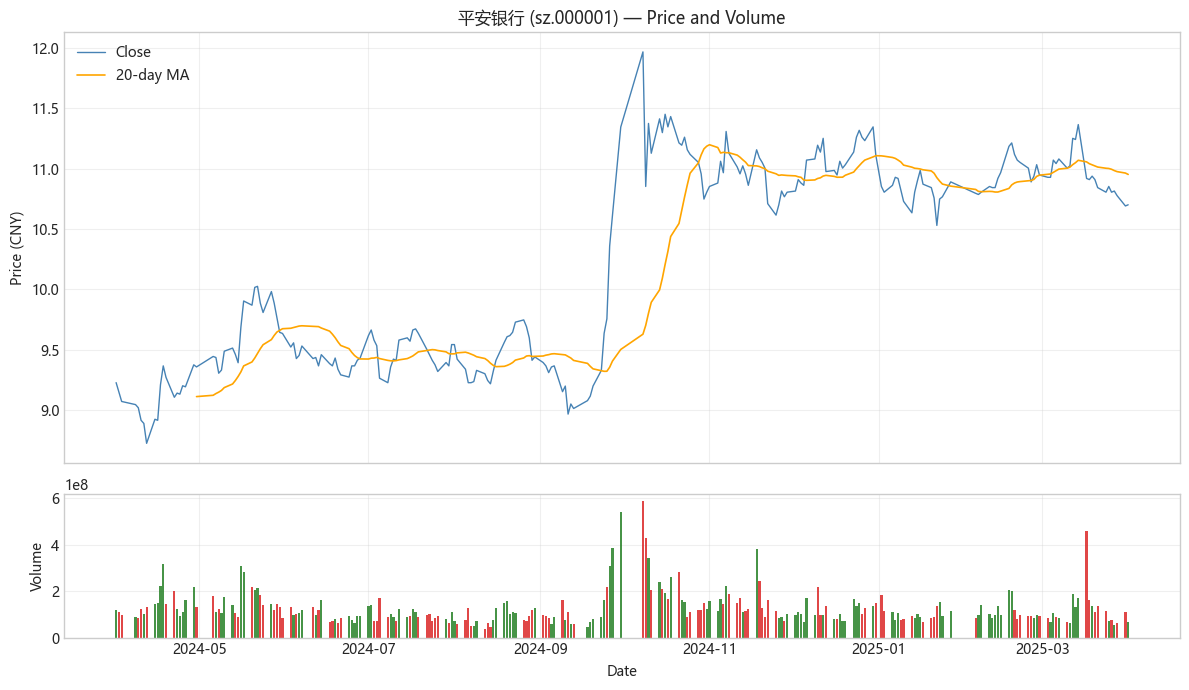

In [15]:
fig, (ax_price, ax_vol) = plt.subplots(
    2, 1,
    figsize=(12, 7),
    sharex=True,
    gridspec_kw={'height_ratios': [3, 1]}
)

# Top panel: price + 20-day moving average
ax_price.plot(df.index, df['close'], color='steelblue', linewidth=1, label='Close')
ax_price.plot(df.index, df['ma_20'], color='orange', linewidth=1.2, label='20-day MA')
ax_price.set_ylabel('Price (CNY)')
ax_price.set_title('平安银行 (sz.000001) — Price and Volume')
ax_price.legend(loc='upper left')
ax_price.grid(True, alpha=0.3)

# Bottom panel: volume bars
ax_vol.bar(df.index, df['volume'], color='grey', alpha=0.6)
ax_vol.set_ylabel('Volume')
ax_vol.set_xlabel('Date')
ax_vol.grid(True, alpha=0.3)

# Set Colors for Volume Bars
colors = ['green' if c >= o else 'red' 
          for c, o in zip(df['close'], df['open'])]
ax_vol.bar(df.index, df['volume'], color=colors, alpha=0.6)

fig.tight_layout()
plt.show()

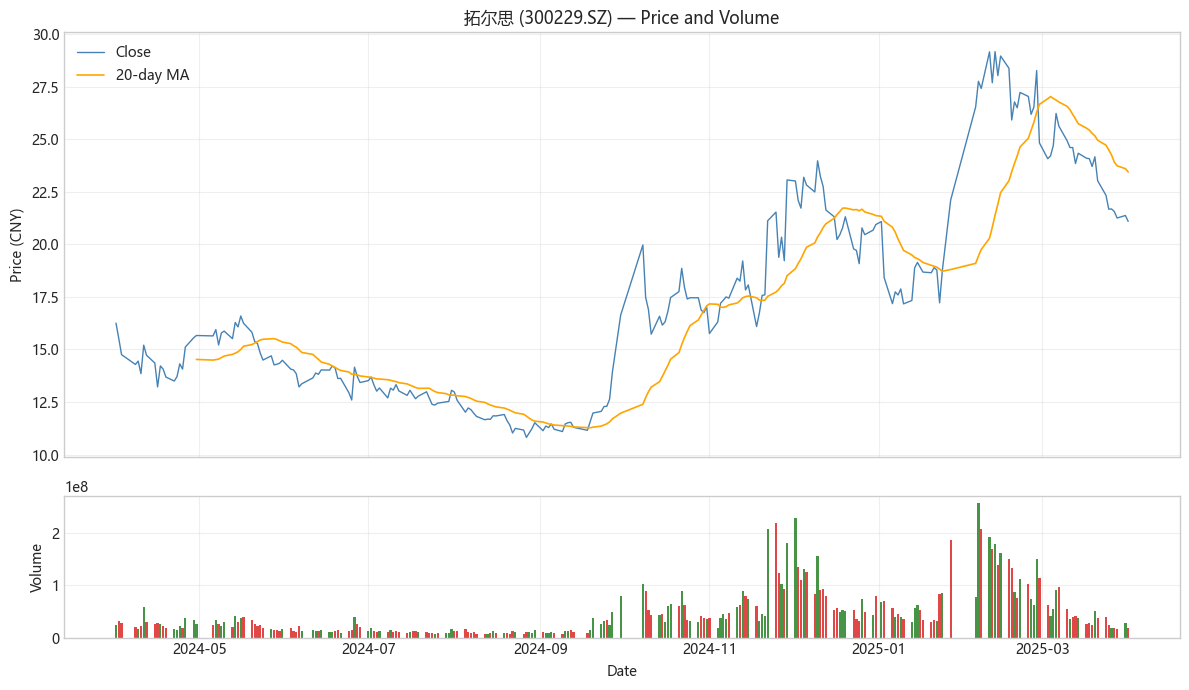

In [22]:
fig, (ax_price, ax_vol) = plt.subplots(
    2, 1,
    figsize=(12, 7),
    sharex=True,
    gridspec_kw={'height_ratios': [3, 1]}
)

# Top panel: price + 20-day moving average
ax_price.plot(df_small.index, df_small['close'], color='steelblue', linewidth=1, label='Close')
ax_price.plot(df_small.index, df_small['ma_20'], color='orange', linewidth=1.2, label='20-day MA')
ax_price.set_ylabel('Price (CNY)')
ax_price.set_title('拓尔思 (300229.SZ) — Price and Volume')
ax_price.legend(loc='upper left')
ax_price.grid(True, alpha=0.3)

# Bottom panel: volume bars
ax_vol.bar(df_small.index, df_small['volume'], color='grey', alpha=0.6)
ax_vol.set_ylabel('Volume')
ax_vol.set_xlabel('Date')
ax_vol.grid(True, alpha=0.3)

# Set Colors for Volume Bars
colors = ['green' if c >= o else 'red' 
          for c, o in zip(df_small['close'], df_small['open'])]
ax_vol.bar(df_small.index, df_small['volume'], color=colors, alpha=0.6)

fig.tight_layout()
plt.show()

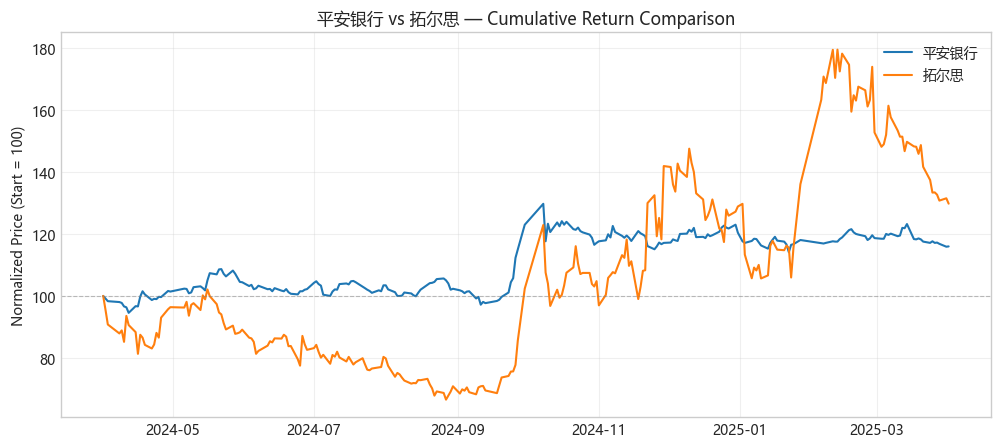

In [27]:
# Normalize both stocks to start at 100
df['close_norm'] = df['close'] / df['close'].iloc[0] * 100
df_small['close_norm'] = df_small['close'] / df_small['close'].iloc[0] * 100

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df.index, df['close_norm'], label='平安银行')
ax.plot(df_small.index, df_small['close_norm'], label='拓尔思')
ax.axhline(100, color='grey', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_ylabel('Normalized Price (Start = 100)')
ax.set_title('平安银行 vs 拓尔思 — Cumulative Return Comparison')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


In [26]:
import os
os.makedirs('charts', exist_ok=True)
fig.savefig('charts/pingan_vs_tuosi_comparison.png', dpi=150, bbox_inches='tight')